# 02 · Signed Integers (Two's Complement) & IEEE 754 Floating Point
**Course:** SLAO · ISG Tunis
**Covers:** TD1 exercises 5, 7, 8, 9, 10, 11 (IEEE part) and 12

---

## Objectives
1. Encode / decode signed integers in **two's complement** and know the range $[-2^{N-1},\,2^{N-1}-1]$.
2. Add and subtract with an *N*-bit adder and **detect overflow** from the flags (Z, N, C, V).
3. Implement the **IEEE 754 single-precision** encoder and decoder from scratch and validate it against
   the reference implementation in Python's `struct` module.
4. Reproduce every TD1 result (two's complement and floating point) with automatic checks.

## Contents
1. Setup
2. Two's complement: range, encoding, decoding
3. Addition, subtraction and overflow flags
4. IEEE 754 single precision: anatomy
5. Encoder, decoder and validation
6. Why floating point is inexact
7. TD1 solutions, checked automatically

## 1 · Setup

In [1]:
from __future__ import annotations
from fractions import Fraction
import struct
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

pd.set_option("display.width", 120)

## 2 · Two's complement

For $N$ bits the representable integers are $[-2^{N-1},\; 2^{N-1}-1]$ (8 bits: $-128\dots127$,
16 bits: $-32768\dots32767$). Note the range is **asymmetric**: there is one more negative value than positive.

**Encoding a negative number $-x$:** write $x$ in binary on $N$ bits, invert every bit (*one's complement*, C1),
then add 1 (*two's complement*, C2). Equivalent formula: $C2(x) = 2^N - x$.

**Decoding:** if the most significant bit (MSB) is 1, the value is $\text{unsigned} - 2^N$.

In [2]:
def twos_range(n_bits: int) -> tuple[int, int]:
    return -(2 ** (n_bits - 1)), 2 ** (n_bits - 1) - 1


def encode_twos(value: int, n_bits: int, trace: bool = False) -> str:
    """Two's-complement encoding. Raises OverflowError when the value does not fit."""
    lo, hi = twos_range(n_bits)
    if not lo <= value <= hi:
        raise OverflowError(f"{value} does not fit on {n_bits} bits (range {lo}..{hi})")
    magnitude = format(abs(value), f"0{n_bits}b")
    if value >= 0:
        return magnitude
    c1 = "".join("1" if b == "0" else "0" for b in magnitude)        # invert all bits
    c2 = format((int(c1, 2) + 1) % 2 ** n_bits, f"0{n_bits}b")        # add 1
    if trace:
        print(f"|{value}|  = {magnitude}\nC1      = {c1}\nC1 + 1  = {c2}")
    return c2


def decode_twos(bits: str) -> int:
    n = len(bits)
    u = int(bits, 2)
    return u - 2 ** n if bits[0] == "1" else u


print("8-bit range :", twos_range(8))
print("16-bit range:", twos_range(16))
encode_twos(-55, 8, trace=True)

8-bit range : (-128, 127)
16-bit range: (-32768, 32767)
|-55|  = 00110111
C1      = 11001000
C1 + 1  = 11001001


'11001001'

## 3 · Addition, subtraction and overflow

Subtraction needs no dedicated circuit: $a - b = a + C2(b)$. After each operation the ALU updates the
**flag register** (see Chapter 4):

| Flag | Meaning | Condition |
|---|---|---|
| **Z** | zero | result = 0 |
| **N** | negative | MSB of result = 1 |
| **C** | carry | carry out of the MSB (*unsigned* overflow) |
| **V** | overflow | *signed* overflow: two operands of the same sign give a result of the opposite sign |

The TD's rule is exactly the V flag: *"the sum of two positives is negative, hence overflow."*

In [3]:
def alu_add(a_bits: str, b_bits: str) -> dict:
    """N-bit addition with the four status flags."""
    n = len(a_bits)
    assert len(b_bits) == n
    raw = int(a_bits, 2) + int(b_bits, 2)
    result = format(raw % 2 ** n, f"0{n}b")
    sa, sb, sr = a_bits[0], b_bits[0], result[0]
    return {
        "result": result,
        "value": decode_twos(result),
        "Z": int(set(result) == {"0"}),
        "N": int(sr == "1"),
        "C": int(raw >= 2 ** n),
        "V": int(sa == sb and sr != sa),
    }


def alu_sub(a_bits: str, b_bits: str) -> dict:
    """a - b computed as a + C2(b); the 'cheat' is only negating b with invert + 1."""
    n = len(a_bits)
    neg_b = format((int("".join("1" if c == "0" else "0" for c in b_bits), 2) + 1) % 2 ** n, f"0{n}b")
    return alu_add(a_bits, neg_b)


def calc(x: int, y: int, n_bits: int = 8, op: str = "+") -> dict:
    ex, ey = encode_twos(x, n_bits), encode_twos(y, n_bits)
    out = alu_add(ex, ey) if op == "+" else alu_sub(ex, ey)
    out |= {"a": ex, "b": ey, "expected": x + y if op == "+" else x - y}
    out["overflow?"] = "YES" if out["V"] else "no"
    return out


demo = [calc(85, 51), calc(43, -15), calc(-55, 26), calc(43, 15, op="-")]
pd.DataFrame(demo)[["a", "b", "result", "value", "expected", "Z", "N", "C", "V", "overflow?"]]

,a,b,result,value,expected,Z,N,C,V,overflow?
0,01010101,00110011,10001000,-120,136,0,1,0,1,YES
1,00101011,11110001,00011100,28,28,0,0,1,0,no
2,11001001,00011010,11100011,-29,-29,0,1,0,0,no
3,00101011,00001111,00011100,28,28,0,0,1,0,no


## 4 · IEEE 754 single precision (32 bits)

$$\text{value} = (-1)^{S} \times 1.M \times 2^{\,E - 127}$$

| Field | Bits | Role |
|---|---|---|
| **S** | 1 (bit 31) | sign: 0 = positive, 1 = negative |
| **E** | 8 (bits 30–23) | **biased** exponent: $E = e + 127$ |
| **M** | 23 (bits 22–0) | fractional part of the normalised mantissa; the leading `1.` is implicit |

**Encoding recipe (the one used in TD1):**
1. Convert the absolute value to binary (integer part + fractional part).
2. Normalise to $1.M \times 2^e$.
3. Add the bias: $E = e + 127$, write on 8 bits.
4. Write the fractional digits of the mantissa, pad with zeros to 23 bits.
5. Set the sign bit.

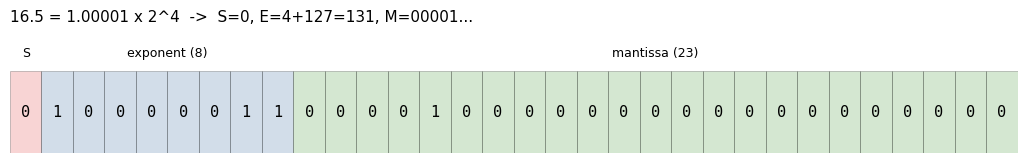

In [4]:
def draw_fields(word: str, title: str = "") -> None:
    """Colour-coded 32-bit word: sign | exponent | mantissa."""
    assert len(word) == 32
    colours = ["#e45756"] * 1 + ["#4c78a8"] * 8 + ["#54a24b"] * 23
    fig, ax = plt.subplots(figsize=(13, 1.6))
    for i, (b, c) in enumerate(zip(word, colours)):
        ax.add_patch(Rectangle((i, 0), 1, 1, facecolor=c, alpha=0.25, edgecolor="black", lw=0.6))
        ax.text(i + 0.5, 0.5, b, ha="center", va="center", family="monospace", fontsize=11)
    for x0, x1, label in [(0, 1, "S"), (1, 9, "exponent (8)"), (9, 32, "mantissa (23)")]:
        ax.text((x0 + x1) / 2, 1.18, label, ha="center", fontsize=9)
    ax.set_xlim(0, 32); ax.set_ylim(0, 1.5); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11, loc="left")
    plt.show()


draw_fields("0" + "10000011" + "00001" + "0" * 18, "16.5 = 1.00001 x 2^4  ->  S=0, E=4+127=131, M=00001...")

## 5 · Encoder, decoder and validation

The encoder works on exact `Fraction`s (no hidden floating-point error) and applies
**round-to-nearest-even**, the IEEE default, so it matches hardware even for values such as 0.1.
Only *normal* numbers are handled (zero is special-cased); subnormals, infinities and NaN are out of the course scope.

In [5]:
def encode_ieee754(x: Fraction | float | int | str) -> str:
    """Return the 32-bit pattern (as a string of 0/1) of a real number."""
    f = Fraction(str(x)) if isinstance(x, (str, float)) else Fraction(x)
    sign = "1" if f < 0 else "0"
    f = abs(f)
    if f == 0:
        return sign + "0" * 31

    # Step 2: normalise so that 1 <= m < 2   (f = m * 2**e)
    e = 0
    m = f
    while m >= 2:
        m /= 2; e += 1
    while m < 1:
        m *= 2; e -= 1
    if not -126 <= e <= 127:
        raise ValueError("exponent out of the normal range (subnormals not supported)")

    # Step 4: mantissa = 23 fractional bits, rounded to nearest even
    scaled = (m - 1) * 2 ** 23
    q, r = divmod(scaled.numerator, scaled.denominator)
    if 2 * r > scaled.denominator or (2 * r == scaled.denominator and q % 2 == 1):
        q += 1
    if q == 2 ** 23:                       # rounding carried into the exponent
        q, e = 0, e + 1

    # Step 3: biased exponent
    return sign + format(e + 127, "08b") + format(q, "023b")


def decode_ieee754(word: str) -> tuple[float, dict]:
    """32-bit pattern -> value, plus a dictionary of every intermediate quantity."""
    s, e, m = int(word[0]), int(word[1:9], 2), word[9:]
    mantissa = Fraction(1) + sum(Fraction(int(b), 2 ** (i + 1)) for i, b in enumerate(m))
    exp = e - 127
    value = (-1) ** s * mantissa * Fraction(2) ** exp
    return float(value), {"sign": s, "E (biased)": e, "e (real)": exp, "1.M": float(mantissa)}


def hex32(word: str) -> str:
    return format(int(word, 2), "08X")


def from_hex32(h: str) -> str:
    return format(int(h, 16), "032b")


# Validation against the reference implementation (struct = the machine's own float32)
def ref_bits(x: float) -> str:
    return format(struct.unpack(">I", struct.pack(">f", x))[0], "032b")


import random
random.seed(1)
samples = [2, 16.5, 6.125, -5 / 32, 0.1, -0.3, 1e-5, 12345.678, 3.4e38] + [random.uniform(-1e6, 1e6) for _ in range(500)]
bad = [x for x in samples if encode_ieee754(x) != ref_bits(x)]
print(f"{len(samples)} values compared with struct.pack('>f'): mismatches = {len(bad)}")
assert not bad

509 values compared with struct.pack('>f'): mismatches = 0


## 6 · Why floating point is inexact

A real number is exactly representable only if it is a sum of powers of two. $0.5, 0.25, 0.125$ are;
$0.1$ is not (its binary expansion repeats forever), so the stored value is the nearest 32-bit approximation.

   0.5 -> 3F000000  stored = 0.5                      error = 0.000e+00
 0.125 -> 3E000000  stored = 0.125                    error = 0.000e+00
   0.1 -> 3DCCCCCD  stored = 0.10000000149011612      error = 1.490e-09


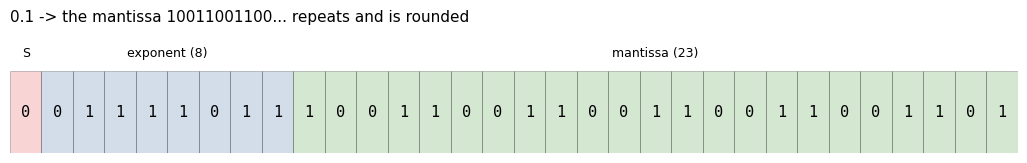

In [6]:
for x in ("0.5", "0.125", "0.1"):
    word = encode_ieee754(x)
    stored, info = decode_ieee754(word)
    print(f"{x:>6} -> {hex32(word)}  stored = {stored!r:<24} error = {abs(Fraction(stored) - Fraction(x)):.3e}")
draw_fields(encode_ieee754("0.1"), "0.1 -> the mantissa 10011001100... repeats and is rounded")

## 7 · TD1 solutions (self-checking)

### Exercise 5 – two's complement on 8 then 16 bits

In [7]:
assert twos_range(8) == (-128, 127) and twos_range(16) == (-32768, 32767)

assert encode_twos(127, 8)  == "01111111"
assert encode_twos(127, 16) == "0000000001111111"
assert encode_twos(-128, 8) == "10000000"                 # -128 fits on 8 bits...
assert decode_twos("10000000") == -128                    # ...and so does the pattern 1000 0000

try:
    encode_twos(-136, 8)
except OverflowError as e:
    print("-136 on 8 bits  ->", e)

assert encode_twos(-136, 16) == "1111111101111000"
print("-136 on 16 bits ->", encode_twos(-136, 16, trace=True))

-136 on 8 bits  -> -136 does not fit on 8 bits (range -128..127)
|-136|  = 0000000010001000
C1      = 1111111101110111
C1 + 1  = 1111111101111000
-136 on 16 bits -> 1111111101111000


### Exercise 7 – operations in two's complement on 8 bits

In [8]:
r1 = calc(85, 51)          # two positives -> negative result  => overflow
assert (r1["result"], r1["V"]) == ("10001000", 1)

r2 = calc(43, -15)         # +43 - 15 = 28 ; the final carry is simply ignored
assert (r2["result"], r2["value"], r2["V"]) == ("00011100", 28, 0)
assert r2["C"] == 1        # the carry exists, but is NOT an error in two's complement

r3 = calc(-55, 26)
assert (r3["result"], r3["value"]) == ("11100011", -29)

pd.DataFrame([r1, r2, r3])[["a", "b", "result", "value", "expected", "C", "V", "overflow?"]]

,a,b,result,value,expected,C,V,overflow?
0,01010101,00110011,10001000,-120,136,0,1,YES
1,00101011,11110001,00011100,28,28,1,0,no
2,11001001,00011010,11100011,-29,-29,0,0,no


**Reading the table**
* `+85 + 51`: two positives yield a negative pattern (`1000 1000` = −120) → **overflow** (V = 1). The true result, 136, exceeds +127.
* `+43 − 15`: C = 1 but V = 0. In two's complement the **carry out is ignored**; only V signals an error.

### Exercise 8 – encode reals in IEEE 754 (32 bits)

     2 -> 0 10000000 00000000000000000000000   = 0x40000000
  16.5 -> 0 10000011 00001000000000000000000   = 0x41840000
 6.125 -> 0 10000001 10001000000000000000000   = 0x40C40000
 -5/32 -> 1 01111100 01000000000000000000000   = 0xBE200000


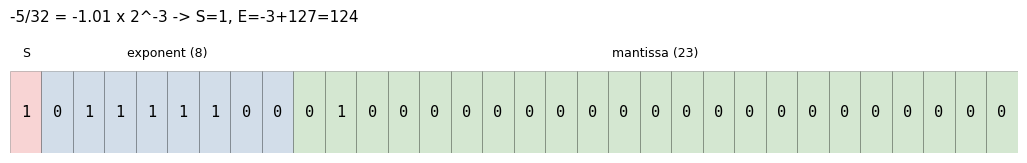

In [9]:
expected = {
    "2":     "0 10000000 00000000000000000000000",
    "16.5":  "0 10000011 00001000000000000000000",
    "6.125": "0 10000001 10001000000000000000000",
    "-5/32": "1 01111100 01000000000000000000000",
}
for x, pattern in expected.items():
    got = encode_ieee754(Fraction(x))
    assert got == pattern.replace(" ", ""), (x, got)
    print(f"{x:>6} -> {got[0]} {got[1:9]} {got[9:]}   = 0x{hex32(got)}")
draw_fields(encode_ieee754(Fraction(-5, 32)), "-5/32 = -1.01 x 2^-3 -> S=1, E=-3+127=124")

### Exercise 10 – decode hexadecimal words

0x42E48000 -> 114.25   {'sign': 0, 'E (biased)': 133, 'e (real)': 6, '1.M': 1.78515625}
0x3F880000 -> 1.0625   {'sign': 0, 'E (biased)': 127, 'e (real)': 0, '1.M': 1.0625}


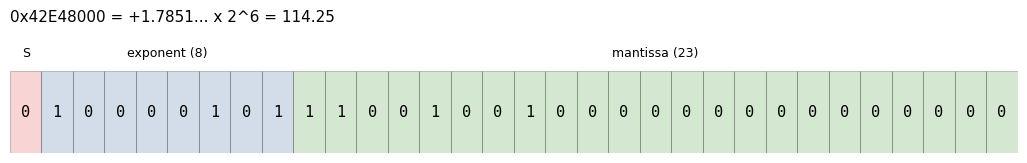

In [10]:
for h, exp in [("42E48000", 114.25), ("3F880000", 1.0625)]:
    val, info = decode_ieee754(from_hex32(h))
    assert val == exp
    print(f"0x{h} -> {val}   {info}")
draw_fields(from_hex32("42E48000"), "0x42E48000 = +1.7851... x 2^6 = 114.25")

### Exercise 11 – hexadecimal `5B7.A34` to IEEE 754
Steps: convert to binary (notebook 01) → normalise → bias → hexadecimal word.

IEEE 754 word: 0 10001001 01101101111010001101000
hexadecimal  : 0x44B6F468


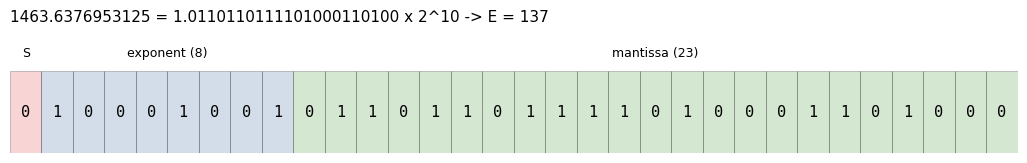

In [11]:
value = Fraction(1463) + Fraction(0xA34, 16 ** 3)            # 5B7 = 1463 ; .A34 = 0xA34 / 16^3
assert value == Fraction("1463.6376953125")

word = encode_ieee754(value)
print("IEEE 754 word:", word[0], word[1:9], word[9:])
print("hexadecimal  : 0x" + hex32(word))
assert hex32(word) == "44B6F468"                              # 8 hex digits, as in the handwritten solution
draw_fields(word, "1463.6376953125 = 1.0110110111101000110100 x 2^10 -> E = 137")

### Exercise 12 – decode a word: sign = 1, exponent = 132, mantissa = `1010101101`

In [12]:
word = "1" + format(132, "08b") + "1010101101" + "0" * 13
print("word:", word, " = 0x" + hex32(word))
val, info = decode_ieee754(word)
print(val, info)
assert val == -53.40625 and hex32(word) == "C255A000"
assert encode_ieee754(Fraction("-53.40625")) == word          # round trip

word: 11000010010101011010000000000000  = 0xC255A000
-53.40625 {'sign': 1, 'E (biased)': 132, 'e (real)': 5, '1.M': 1.6689453125}


> **Note for the reader.** The handwritten solution writes the exponent field as `1000101` (7 digits). A valid
> field has 8 bits; the stated real exponent 5 and the result −53.40625 both require `10000100` (= 132), which is
> the value used above.

## Summary

| Concept | Key formula | Function |
|---|---|---|
| Signed range on *N* bits | $[-2^{N-1},\,2^{N-1}-1]$ | `twos_range` |
| Negate | invert bits, add 1 | `encode_twos` |
| Overflow (signed) | same-sign operands, opposite-sign result (flag V) | `alu_add` |
| Carry (unsigned) | carry out of MSB (flag C) – ignored in two's complement | `alu_add` |
| IEEE 754 single | $(-1)^S\,1.M\,2^{E-127}$ | `encode_ieee754`, `decode_ieee754` |

**Next:** `03_boolean_algebra_and_karnaugh.ipynb` – logic functions and their minimisation.